# Course 2: Python Project 04 PART-1: EDA & Data Preprocessing on Google App Store Rating Dataset.

The Play Store apps data has enormous potential to drive app-making businesses to success. However, many
apps are being developed every single day and only a few of them become profitable. It is important for
developers to be able to predict the success of their app and incorporate features which makes an app
successful. Before any such predictive-study can be done, it is necessary to do EDA and data-preprocessing on
the apps data available for google app store applications. From the collected apps data and user ratings from
the app stores, let's try to extract insightful information.

### 1. Import required libraries and read the dataset.

In [1]:
 #importing required libraries
    
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 

In [3]:
#reading dataset

Apps_data=pd.read_csv("Apps_data+(1).csv")

### 2. Check the first few samples, shape, info of the data and try to familiarize yourself with different features

In [4]:
#checking few samples of dataset
Apps_data.head()     

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [5]:
    Apps_data.tail()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


In [6]:
Apps_data.shape

(10841, 13)

In [7]:
Apps_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


Note:

There are 13 columns present in dataset, in which except Rating column  all other columns are have object type data, and Rating column have float type data, total entries in dataset is 10841. 

### 3. Check summary statistics of the dataset. List out the columns that need to be worked upon for model building.

In [8]:
#summary statistics for numaric data
Apps_data.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


Note:

Total count of Rating column in dataset is 9367, the everage rating for app is 4.2, and the variation in rating is 0.5, the minimum rating in dataset is 1 and maximum rating is 19 which is an outlier, the 25% rating in dataset is below 4, the 50% rating in dataset is below 4.3, the 75% rating in dataset is below 4.5.

In [9]:
#summary statistics for object data type column
Apps_data.describe(include="object")

,App,Category,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,596,1695,1579,10039,10040,8714,842,326,1459,2451


Note:

- The total count of apps is 10841, there are 9660 apps are unique in dataset, top app is ROBLOX, and the frequency is 9
- The total count of Category is 10841, there are 34 unique categories in dataset, top Category is FAMILY, and the frequency is 1972
- The total count of Review is 10841, there are 6002 unique reviews in dataset for app, and the frequency is 596
- The total count of apps size is 10841, there are 462 unique size in dataset, top Size is Varies with device, and the frequency is 1695
- The total count of installs is 10841, there are 22 apps are unique in dataset which are install, and the frequency is 1579
- The total count of Type is 10840, there are 3 apps type are unique in dataset, top app type is is Free, and the frequency is 10039
- The total count of app price is 10841, there are 93 apps price are unique in dataset, and the frequency is 10040
- The total count of apps Content Rating is 10840, there are 6 apps Content Rating are unique in dataset, top app Content Rating is Everyone, and the frequency is 8714
- The total count of apps Genres is 10841, there are 120 apps genres are unique in dataset, top app genres is Tools, and the frequency is 842
- The total count of apps Last updation is 10841, there are 1378 apps last updation are unique in dataset, and the frequency is 326
- The total count of current version apps is 10833, there are 2832 app are unique with current version in dataset, and the frequency is 1459
- The total count of android version apps is 10838, there are 33 apps are unique with android version in dataset, and the frequency for that is 2451

We need to work on all the columns which are have object type data for modeling. i.e. App, Category, Reviews, Size, Installs, Type, Price, Content Rating, Genres, Last Updated, Current Ver, Android Ver 

### 4. Check if there are any duplicate records in the dataset? if any drop them.

In [10]:
#checking for number of duplicates in the dataset
Apps_data.duplicated().sum()

483

Note:

There 483 duplicates present in dataset

In [11]:
#displaying duplicates
Apps_data[Apps_data.duplicated()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
229,Quick PDF Scanner + OCR FREE,BUSINESS,4.2,80805,Varies with device,"5,000,000+",Free,0,Everyone,Business,"February 26, 2018",Varies with device,4.0.3 and up
236,Box,BUSINESS,4.2,159872,Varies with device,"10,000,000+",Free,0,Everyone,Business,"July 31, 2018",Varies with device,Varies with device
239,Google My Business,BUSINESS,4.4,70991,Varies with device,"5,000,000+",Free,0,Everyone,Business,"July 24, 2018",2.19.0.204537701,4.4 and up
256,ZOOM Cloud Meetings,BUSINESS,4.4,31614,37M,"10,000,000+",Free,0,Everyone,Business,"July 20, 2018",4.1.28165.0716,4.0 and up
261,join.me - Simple Meetings,BUSINESS,4.0,6989,Varies with device,"1,000,000+",Free,0,Everyone,Business,"July 16, 2018",4.3.0.508,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8643,Wunderlist: To-Do List & Tasks,PRODUCTIVITY,4.6,404610,Varies with device,"10,000,000+",Free,0,Everyone,Productivity,"April 6, 2018",Varies with device,Varies with device
8654,"TickTick: To Do List with Reminder, Day Planner",PRODUCTIVITY,4.6,25370,Varies with device,"1,000,000+",Free,0,Everyone,Productivity,"August 6, 2018",Varies with device,Varies with device
8658,ColorNote Notepad Notes,PRODUCTIVITY,4.6,2401017,Varies with device,"100,000,000+",Free,0,Everyone,Productivity,"June 27, 2018",Varies with device,Varies with device
10049,Airway Ex - Intubate. Anesthetize. Train.,MEDICAL,4.3,123,86M,"10,000+",Free,0,Everyone,Medical,"June 1, 2018",0.6.88,5.0 and up


In [12]:
#droping duplicates
drop_duplicates_apps_data = Apps_data.drop_duplicates()

In [13]:
drop_duplicates_apps_data.duplicated().sum()

0

Note:

Now the all duplicates are removed from the dataset

In [14]:
#taking the copy of data

apps_df=drop_duplicates_apps_data.copy()

### 5. Check the unique categories of the column 'Category', Is there any invalid category? If yes, drop them.

In [15]:
#checking for unique categories
apps_df["Category"].value_counts()

Category
FAMILY                 1943
GAME                   1121
TOOLS                   843
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         388
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     230
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       85
WEATHER                  82
HOUSE_AND_HOME           80
ART_AND_DESIGN           65
EVENTS                   64
PARENTING                60
COMICS                   60
BEAUTY                   53
1.9                       1
Name: count, dtype: int64

Note:

The "1.9"Category is invalid in that Category column becouse its not indicating any meaning for that category column

In [16]:
#droping invalid category
apps_df=apps_df[apps_df["Category"]!='1.9']

In [17]:
apps_df["Category"].value_counts()

Category
FAMILY                 1943
GAME                   1121
TOOLS                   843
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         388
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     230
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       85
WEATHER                  82
HOUSE_AND_HOME           80
ART_AND_DESIGN           65
EVENTS                   64
PARENTING                60
COMICS                   60
BEAUTY                   53
Name: count, dtype: int64

Note:

Now the invalid category is dropped in the dataset

### 6. Check if there are missing values present in the column Rating, If any? drop them and and create a new column as 'Rating_category' by converting ratings to high and low categories(>3.5 is high rest low)

In [18]:
#Checking for missing values in rating column
apps_df["Rating"].isnull().sum()

1465

Note:

There are 1465 missing values present in rating column

In [19]:
#dropping the missing values 
apps_df=apps_df.dropna(subset="Rating")

In [20]:
apps_df["Rating"].isnull().sum()

0

Note:

All the missing values are dropped from rating column in dataset

In [21]:
#defining function category_rating for converting ratings to high and low categories(>3.5 is high rest low)

def category_rating(rating):
     return 'High' if rating > 3.5 else 'Low'

In [22]:
#creating a new column Rating_category by converting ratings to high and low categories

apps_df["Rating_category"]=apps_df["Rating"].apply(category_rating)   

In [23]:
apps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Rating_category
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,High
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,High
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,High
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,High
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,High


Note:

Now the new column called "Rating_category" is created in the dataset

### 7. Check the distribution of the newly created column 'Rating_category' and comment on the distribution.


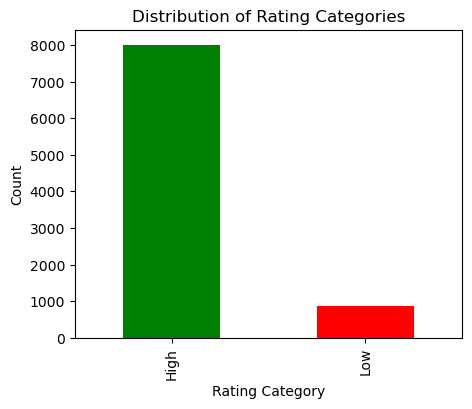

In [24]:
# Plot for 'Rating_category' to check distribution

plt.figure(figsize=(5, 4))
apps_df['Rating_category'].value_counts().plot(kind='bar', color=['green', 'red'],)
plt.title('Distribution of Rating Categories')
plt.xlabel('Rating Category')
plt.ylabel('Count')
plt.show()

Note:

The high rating count is more as compare to low rating count, that means in that dataset more apps are liking by people

In [25]:
#Checking the distribution of 'Rating_category'
apps_df["Rating_category"].value_counts()

Rating_category
High    8012
Low      880
Name: count, dtype: int64

Note:

The total High rating count is 8012 and the total low rating count is 880

### 8. Convert the column "Reviews'' to numeric data type and check the presence of outliers in the column and handle the outliers using a transformation approach.(Hint: Use log transformation)

In [26]:
#converting the column Reviews to numeric data
apps_df["Reviews"]=apps_df["Reviews"].astype(float)

In [27]:
apps_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8892 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   App              8892 non-null   object 
 1   Category         8892 non-null   object 
 2   Rating           8892 non-null   float64
 3   Reviews          8892 non-null   float64
 4   Size             8892 non-null   object 
 5   Installs         8892 non-null   object 
 6   Type             8892 non-null   object 
 7   Price            8892 non-null   object 
 8   Content Rating   8892 non-null   object 
 9   Genres           8892 non-null   object 
 10  Last Updated     8892 non-null   object 
 11  Current Ver      8888 non-null   object 
 12  Android Ver      8890 non-null   object 
 13  Rating_category  8892 non-null   object 
dtypes: float64(2), object(12)
memory usage: 1.0+ MB


Note:

Now the Reviews column is converted to float type data

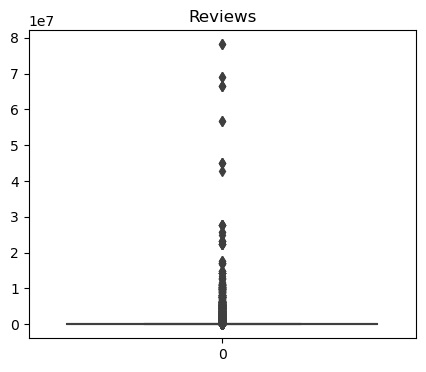

In [28]:
#checking for outliers in reviews column
plt.figure(figsize=(5,4))
sns.boxplot(apps_df["Reviews"])
plt.title("Reviews")
plt.show()

Note:

Outliers are present in Reviews column

In [29]:
#removing outliers using log transformation in reviews column
apps_df["Reviews"]=np.log1p(apps_df["Reviews"])

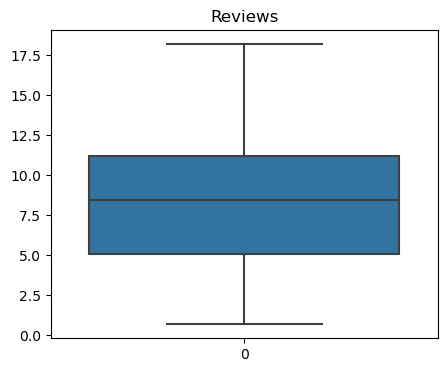

In [30]:
#checking for outliers again
plt.figure(figsize=(5,4))
sns.boxplot(apps_df["Reviews"])
plt.title("Reviews")
plt.show()

Note:

Now the outliers are removed from reviews column

### 9. The column 'Size' contains alphanumeric values, treat the non numeric data and convert the column into suitable data type. (hint: Replace M with 1 million and K with 1 thousand, and drop the entries where size='Varies with device')

In [31]:
apps_df["Size"]

0                       19M
1                       14M
2                      8.7M
3                       25M
4                      2.8M
                ...        
10834                  2.6M
10836                   53M
10837                  3.6M
10839    Varies with device
10840                   19M
Name: Size, Length: 8892, dtype: object

In [32]:
#checking for unique values in "Size"column
apps_df["Size"].value_counts()

Size
Varies with device    1468
14M                    154
13M                    152
12M                    151
11M                    150
                      ... 
383k                     1
454k                     1
812k                     1
442k                     1
619k                     1
Name: count, Length: 414, dtype: int64

In [33]:
#droping he entries where size='Varies with device'
apps_df=apps_df[apps_df["Size"]!="Varies with device"]
apps_df["Size"]

0         19M
1         14M
2        8.7M
3         25M
4        2.8M
         ... 
10833    619k
10834    2.6M
10836     53M
10837    3.6M
10840     19M
Name: Size, Length: 7424, dtype: object

In [34]:
#Defining a function to replace M with 1 million and K with 1 thousand in "size" column

def units_cleaning(string):
    if "k" in string:
        return float(string.split("k")[0])*1000
    
    if "M" in string:
        return float(string.split("M")[0])*1000000

In [35]:
#replacing  M with 1 million and K with 1 thousand in "size" column
apps_df["Size"]=apps_df["Size"].apply(units_cleaning)

In [36]:
apps_df["Size"]

0        19000000.0
1        14000000.0
2         8700000.0
3        25000000.0
4         2800000.0
            ...    
10833      619000.0
10834     2600000.0
10836    53000000.0
10837     3600000.0
10840    19000000.0
Name: Size, Length: 7424, dtype: float64

Note:

Now the Size column is converted into float type data

### 10. Check the column 'Installs', treat the unwanted characters and convert the column into a suitable data type.

In [37]:
#for removing unwanted characters checking the column Installs  
apps_df["Installs"].value_counts()

Installs
1,000,000+        1230
100,000+          1003
10,000+            949
10,000,000+        762
1,000+             675
5,000,000+         493
500,000+           471
50,000+            432
5,000+             414
100+               297
500+               195
100,000,000+       192
50,000,000+        144
10+                 67
50+                 56
500,000,000+        24
5+                   9
1,000,000,000+       8
1+                   3
Name: count, dtype: int64

In [38]:
apps_df["Installs"]=apps_df["Installs"].str.replace(",","")  #replacing , with blank
apps_df["Installs"]=apps_df["Installs"].str.replace("+","") #replacing + with blank

In [39]:
#converting "Installs" to numaric data

apps_df["Installs"]=apps_df["Installs"].apply(pd.to_numeric)

In [40]:
apps_df["Installs"]

0           10000
1          500000
2         5000000
3        50000000
4          100000
           ...   
10833        1000
10834         500
10836        5000
10837         100
10840    10000000
Name: Installs, Length: 7424, dtype: int64

Note:

Now the Installs column is converted into float type data

### 11. Check the column 'Price' , remove the unwanted characters and convert the column into a suitable data type.

In [41]:
#for removing unwanted characters checking the column Price 
apps_df["Price"].value_counts()

Price
0          6877
$0.99       104
$2.99        98
$4.99        61
$1.99        53
           ... 
$6.49         1
$1.29         1
$299.99       1
$379.99       1
$1.20         1
Name: count, Length: 68, dtype: int64

In [42]:
#replacing $ with blank

apps_df["Price"]=apps_df["Price"].str.replace("$","")

In [43]:
#converting "Price" to numaric data

apps_df["Price"]=apps_df["Price"].apply(pd.to_numeric)

In [44]:
apps_df["Price"]

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
10833    0.0
10834    0.0
10836    0.0
10837    0.0
10840    0.0
Name: Price, Length: 7424, dtype: float64

Note:

Now the Price column is converted into float type data

### 12. Drop the columns which you think redundant for the analysis.(suggestion: drop column 'rating', since we created a new feature from it (i.e. rating_category) and the columns 'App', 'Rating' ,'Genres','Last Updated', Current Ver','Android Ver' columns since which are redundant for our analysis)

In [45]:
#droping all columns which are redundant
finel_apps_df=apps_df.drop(columns=["App","Rating","Genres","Last Updated","Current Ver","Android Ver"])

In [46]:
apps_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7424 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   App              7424 non-null   object 
 1   Category         7424 non-null   object 
 2   Rating           7424 non-null   float64
 3   Reviews          7424 non-null   float64
 4   Size             7424 non-null   float64
 5   Installs         7424 non-null   int64  
 6   Type             7424 non-null   object 
 7   Price            7424 non-null   float64
 8   Content Rating   7424 non-null   object 
 9   Genres           7424 non-null   object 
 10  Last Updated     7424 non-null   object 
 11  Current Ver      7420 non-null   object 
 12  Android Ver      7422 non-null   object 
 13  Rating_category  7424 non-null   object 
dtypes: float64(4), int64(1), object(9)
memory usage: 870.0+ KB


In [47]:
#all all redundant columns are dropped
finel_apps_df

,Category,Reviews,Size,Installs,Type,Price,Content Rating,Rating_category
0,ART_AND_DESIGN,5.075174,19000000.0,10000,Free,0.0,Everyone,High
1,ART_AND_DESIGN,6.875232,14000000.0,500000,Free,0.0,Everyone,High
2,ART_AND_DESIGN,11.379520,8700000.0,5000000,Free,0.0,Everyone,High
3,ART_AND_DESIGN,12.281389,25000000.0,50000000,Free,0.0,Teen,High
4,ART_AND_DESIGN,6.875232,2800000.0,100000,Free,0.0,Everyone,High
...,...,...,...,...,...,...,...,...
10833,BOOKS_AND_REFERENCE,3.806662,619000.0,1000,Free,0.0,Everyone,High
10834,FAMILY,2.079442,2600000.0,500,Free,0.0,Everyone,High
10836,FAMILY,3.663562,53000000.0,5000,Free,0.0,Everyone,High
10837,FAMILY,1.609438,3600000.0,100,Free,0.0,Everyone,High


### 13. Encode the categorical columns.

In [48]:
finel_apps_df.select_dtypes("object").columns

Index(['Category', 'Type', 'Content Rating', 'Rating_category'], dtype='object')

In [49]:
#listing out the columns which have object datatype
obj_columns=['Category', 'Type', 'Content Rating', 'Rating_category']

In [50]:
#applying label encoding to listed object datatype column
for col in obj_columns:
    finel_apps_df[col]=label_encoder.fit_transform(finel_apps_df[col])

In [51]:
finel_apps_df

,Category,Reviews,Size,Installs,Type,Price,Content Rating,Rating_category
0,0,5.075174,19000000.0,10000,0,0.0,1,0
1,0,6.875232,14000000.0,500000,0,0.0,1,0
2,0,11.379520,8700000.0,5000000,0,0.0,1,0
3,0,12.281389,25000000.0,50000000,0,0.0,4,0
4,0,6.875232,2800000.0,100000,0,0.0,1,0
...,...,...,...,...,...,...,...,...
10833,3,3.806662,619000.0,1000,0,0.0,1,0
10834,11,2.079442,2600000.0,500,0,0.0,1,0
10836,11,3.663562,53000000.0,5000,0,0.0,1,0
10837,11,1.609438,3600000.0,100,0,0.0,1,0


### 14. Segregate the target and independent features (Hint: Use Rating_category as the target)

In [52]:
#Segregating the target and independent features

X=finel_apps_df.drop(columns="Rating_category")   #independent features
y=finel_apps_df["Rating_category"]                #target feature

### 15. Split the dataset into train and test.

In [53]:
#spliting the dataset as train and test

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=1)

### 16. Standardize the data, so that the values are within a particular range.

In [54]:
#Standardizing the data by using Minmax scaler

from sklearn.preprocessing import MinMaxScaler
minmax_scaler=MinMaxScaler()

In [55]:
X_train

,Category,Reviews,Size,Installs,Type,Price,Content Rating
8888,0,0.693147,2900000.0,100,0,0.00,1
1298,15,12.120858,57000000.0,5000000,0,0.00,1
6599,20,5.736572,5900000.0,10000,0,0.00,1
7328,30,5.365976,6100000.0,5000,1,3.99,1
5681,18,4.060443,5800000.0,10000,0,0.00,1
...,...,...,...,...,...,...,...
1522,17,6.291569,99000000.0,50000,0,0.00,1
7755,11,3.401197,37000000.0,1000,0,0.00,2
5978,11,0.693147,2000000.0,50,1,1.49,1
347,6,15.381183,11000000.0,500000000,0,0.00,1


In [56]:
#Standardizing X_train data
X_train.iloc[:,:]=minmax_scaler.fit_transform(X_train.iloc[:,:])

In [57]:
X_train

,Category,Reviews,Size,Installs,Type,Price,Content Rating
8888,0.00000,0.000000,0.028835,9.900000e-08,0,0.000000,0.2
1298,0.46875,0.675131,0.569927,4.999999e-03,0,0.000000,0.2
6599,0.62500,0.297957,0.058840,9.999000e-06,0,0.000000,0.2
7328,0.93750,0.276063,0.060840,4.999000e-06,1,0.009975,0.2
5681,0.56250,0.198934,0.057840,9.999000e-06,0,0.000000,0.2
...,...,...,...,...,...,...,...
1522,0.53125,0.330746,0.989998,4.999900e-05,0,0.000000,0.2
7755,0.34375,0.159987,0.369893,9.990000e-07,0,0.000000,0.4
5978,0.34375,0.000000,0.019833,4.900000e-08,1,0.003725,0.2
347,0.18750,0.867745,0.109849,5.000000e-01,0,0.000000,0.2


X_train data get standardized now, and the standardized data range is -3 to 3

In [58]:
X_test

,Category,Reviews,Size,Installs,Type,Price,Content Rating
5708,29,6.553933,7300000.0,100000,0,0.00,1
7215,11,5.897154,14000000.0,1000,1,2.99,2
1350,15,11.174231,49000000.0,1000000,0,0.00,1
5727,29,11.272509,6300000.0,1000000,0,0.00,1
5326,11,9.205629,3700000.0,100000,0,0.00,4
...,...,...,...,...,...,...,...
6351,29,7.062192,350000.0,100000,0,0.00,1
1634,18,8.043984,13000000.0,100000,0,0.00,1
9865,3,3.526361,37000000.0,1000,0,0.00,1
10396,11,12.309044,94000000.0,5000000,0,0.00,4


In [59]:
#Standardizing X_test data
X_test.iloc[:,:]=minmax_scaler.fit_transform(X_test.iloc[:,:])

In [60]:
X_test

,Category,Reviews,Size,Installs,Type,Price,Content Rating
5708,0.90625,0.356404,0.072921,9.999900e-05,0,0.000000,0.25
7215,0.34375,0.316464,0.139927,9.990000e-07,1,0.007475,0.50
1350,0.46875,0.637372,0.489957,9.999990e-04,0,0.000000,0.25
5727,0.90625,0.643348,0.062920,9.999990e-04,0,0.000000,0.25
5326,0.34375,0.517658,0.036918,9.999900e-05,0,0.000000,1.00
...,...,...,...,...,...,...,...
6351,0.90625,0.387312,0.003415,9.999900e-05,0,0.000000,0.25
1634,0.56250,0.447017,0.129926,9.999900e-05,0,0.000000,0.25
9865,0.09375,0.172292,0.369946,9.990000e-07,0,0.000000,0.25
10396,0.34375,0.706382,0.939995,4.999999e-03,0,0.000000,1.00


X_test data get standardized now, and the standardized data range is -3 to 3

# Course 2: Python Project 04 PART-2: Data Visualization on Honey Production dataset using seaborn and matplotlib libraries.

In 2006, a global concern was raised over the rapid decline in the honeybee population, an integral component
to American honey agriculture. Large numbers of hives were lost to “Colony-Collapse-Disorder”, a
phenomenon of disappearing “worker-bees” causing the remaining “hive-colony” to collapse. Speculation
around the cause of this disorder points to hive-diseases and pesticides harming the pollinators, though no
overall consensus has been reached. Twelve years later, some industries are observing recovery but the
American honey industry is still largely struggling. The U.S. used to locally produce over half the honey it
consumes per year. Now, honey mostly comes from overseas, with 350 of the 400 million pounds of honey
consumed every year originating from imports. This dataset provides insight into honey production supply and
demand in America by state from 1998 to 2012.

### 1. Import required libraries and read the dataset.

The required libraries are imported in first and second cell of this nootbook file

In [61]:
#reading the dataset

honey_df=pd.read_csv("honeyproduction.csv")

### 2. Check the first few samples, shape, info of the data and try to familiarize yourself with different features.

In [62]:
#checking few samples of dataset
honey_df.head()

,state,numcol,yieldpercol,totalprod,stocks,priceperlb,prodvalue,year
0,AL,16000.0,71,1136000.0,159000.0,0.72,818000.0,1998
1,AZ,55000.0,60,3300000.0,1485000.0,0.64,2112000.0,1998
2,AR,53000.0,65,3445000.0,1688000.0,0.59,2033000.0,1998
3,CA,450000.0,83,37350000.0,12326000.0,0.62,23157000.0,1998
4,CO,27000.0,72,1944000.0,1594000.0,0.70,1361000.0,1998


In [63]:
honey_df.tail()

,state,numcol,yieldpercol,totalprod,stocks,priceperlb,prodvalue,year
621,VA,4000.0,41,164000.0,23000.0,3.77,618000.0,2012
622,WA,62000.0,41,2542000.0,1017000.0,2.38,6050000.0,2012
623,WV,6000.0,48,288000.0,95000.0,2.91,838000.0,2012
624,WI,60000.0,69,4140000.0,1863000.0,2.05,8487000.0,2012
625,WY,50000.0,51,2550000.0,459000.0,1.87,4769000.0,2012


In [64]:
honey_df.shape

(626, 8)

In [65]:
honey_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 626 entries, 0 to 625
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   state        626 non-null    object 
 1   numcol       626 non-null    float64
 2   yieldpercol  626 non-null    int64  
 3   totalprod    626 non-null    float64
 4   stocks       626 non-null    float64
 5   priceperlb   626 non-null    float64
 6   prodvalue    626 non-null    float64
 7   year         626 non-null    int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 39.3+ KB


Note:

There are 8 columns present in dataset, in which except state and yieldpercol column all other columns are have float type data, and state column have object type data, yieldpercol have integer type data, total entries in dataset is 626. 

- The state column have Different states' names.
- numcol column indicating Number of honey producing colonies.
- yieldpercol column indicating Honey yield per colony. (Unit is pounds)
- totalprod column indicating Total production (numcol x yieldpercol). (Unit is pounds)
- stocks column indicating Refers to stocks held by producers. Unit is pounds
- priceperlb column indicating Refers to average price per pound based on expanded sales. Unit is dollars.
- prodvalue column indicating Value of production (total prod x priceperlb). Unit is dollars.
- year column indicating Calendar year.

### 3. Display the percentage distribution of the data in each year using the pie chart.

In [66]:
#Displaying the percentage distribution of the data in each year
(honey_df["year"].value_counts()/626)*100

year
2001    7.028754
2002    7.028754
2003    7.028754
1998    6.869010
1999    6.869010
2000    6.869010
2004    6.549521
2005    6.549521
2006    6.549521
2007    6.549521
2008    6.549521
2009    6.389776
2010    6.389776
2011    6.389776
2012    6.389776
Name: count, dtype: float64

In [67]:
honey_df.year.unique()

array([1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,
       2009, 2010, 2011, 2012], dtype=int64)

In [68]:
year_labels=[2001, 2002, 2003,1998,1999 , 2000, 2004, 2005, 2006, 2007, 2008,2009, 2010, 2011, 2012]

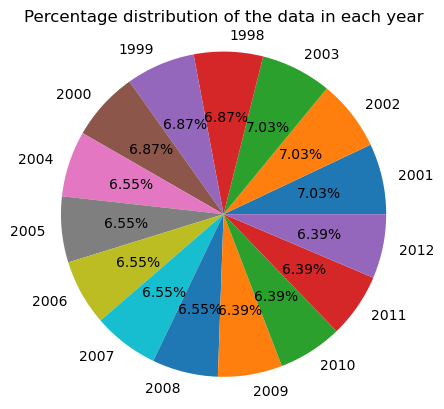

In [69]:
#plotting the percentage distribution of the data in each year using the pie chart.

plt.pie(honey_df["year"].value_counts(),autopct="%.2f%%",radius=1.1,labels=year_labels)
plt.title("Percentage distribution of the data in each year")
plt.show()

Note:

- As compare to other years in dataset, The data distribution is more in the year 2001, 2002 and 2003 i.e about 7.03% 
- As compare to other years in dataset, The data distribution is less in the year 2009, 2010, 2011 and 2012 i.e about 6.39% 

### 4. Plot and Understand the distribution of the variable "price per lb" using displot, and write your findings.

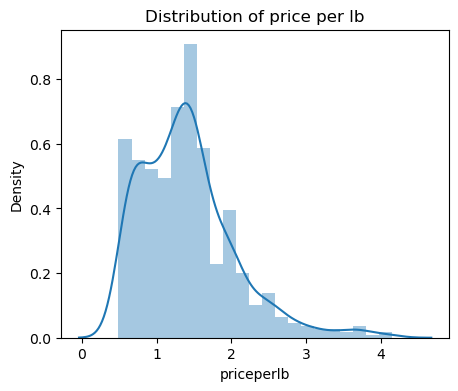

In [70]:
plt.figure(figsize=(5,4))
sns.distplot(honey_df["priceperlb"]) 
plt.title("Distribution of price per lb")
plt.show()

### 5. Plot and understand the relationship between the variables 'numcol' and 'prodval' through scatterplot, and write your findings.

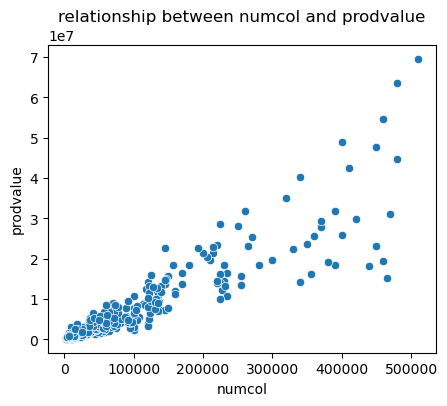

In [71]:
plt.figure(figsize=(5,4))
sns.scatterplot(x=honey_df["numcol"],y=honey_df["prodvalue"])
plt.title("relationship between numcol and prodvalue")
plt.show()

Note:

- There is positive correlation between Number of honey producing colonies and Value of production (total prod x priceperlb) as the number of honey producing colonies are increasing the value of production is also increasing

### 6. Plot and understand the relationship between categorical variable 'year' and a numerical variable 'prodvalue' through boxplot, and write your findings.

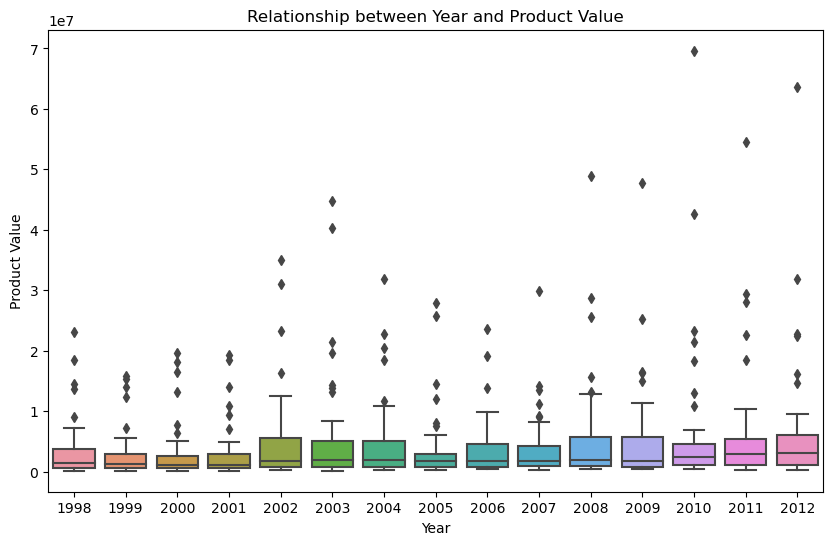

In [72]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='year', y='prodvalue', data=honey_df)
plt.title('Relationship between Year and Product Value')
plt.xlabel('Year')
plt.ylabel('Product Value')
plt.show()

Note:

-  there is no potential relationship between the year and the product value becouse the median value is not changing significantly across years.
- There is more variability in product value during the year 2002,2003,2004, 2008, 2009, 2011, and 2012 becouseof the spread (interquartile range) of the boxes.
- The outliers are present in each years for product value, but the peak outlier is in the year 2010. that means unusual or extreme product value is in the year 2010.

### 7. Visualize and understand the relationship between the multiple pairs of variables throughout different years using pairplot and add your inferences. (use columns 'numcol', 'yield percol', 'total prod', 'prodvalue','year')

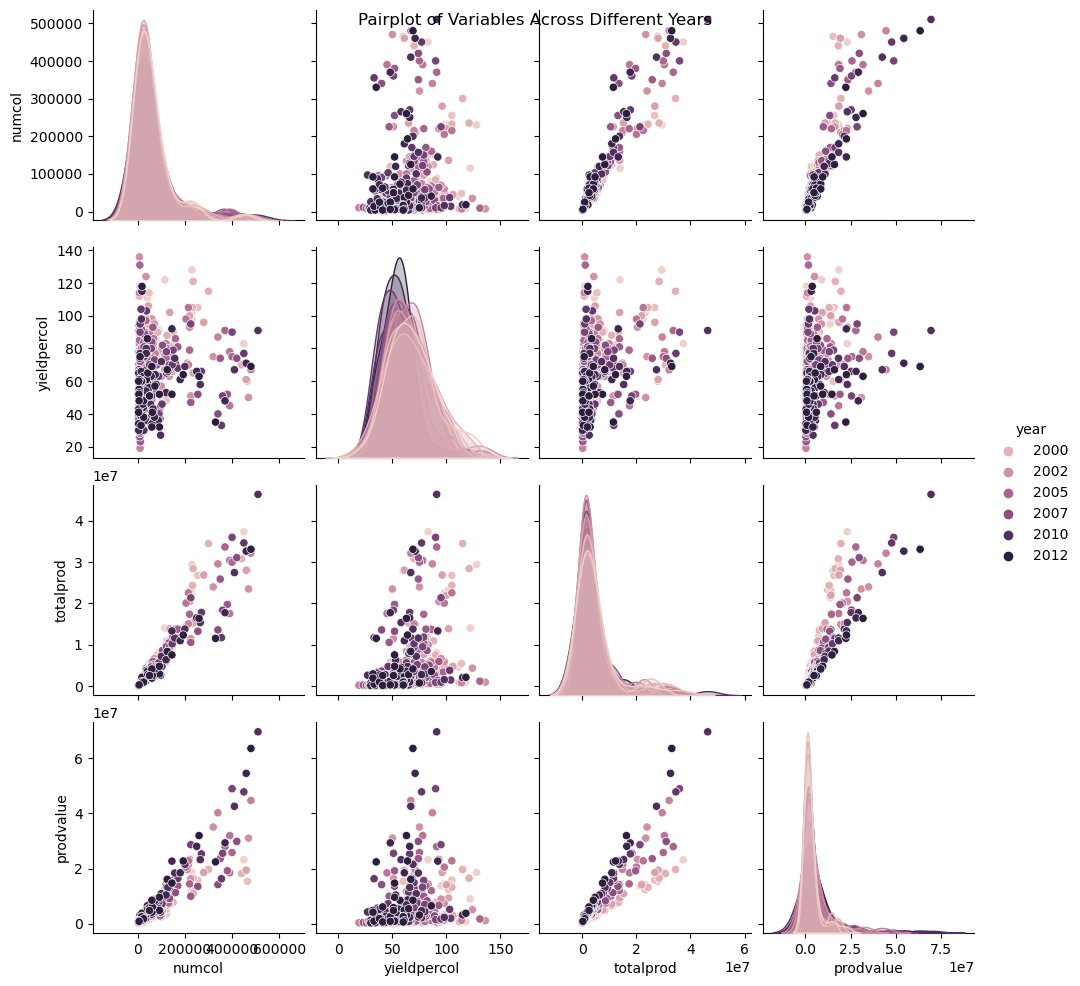

In [73]:
# Filter the DataFrame to include only the required columns
selected_columns = ['numcol', 'yieldpercol', 'totalprod', 'prodvalue', 'year']
honey_df_selected = honey_df[selected_columns]

# Create pairplot
sns.pairplot(honey_df_selected, hue='year')
plt.suptitle('Pairplot of Variables Across Different Years')
plt.show()

Note:

- There is strong positive correlation between Number of honey producing colonies and total production, and also between Number of honey producing colonies and value of production. The one more thing which we can observe in these two plots is the dark dots are more that means in the year 2012 these variable were more strongly correlated with each other.
- And also there is stong positive correlation between total production and value of production. here also we can observe the light color dots are more that means in the year 2000 and 2002 these variable were more strongly correlated with each other.
- And there is correlation between numcol vs yieldpercol, yieldpercol vs production value, and also yieldpercol vs total production, but these variables are not much strongly correlated with each other but we can say there is correlation. here also we can observe the dark dots colors are more visible to eyes that means in the year 2012 these variables were more correlated with each other.


### 8. Display the correlation values using a plot and add your inferences. (use columns 'numcol', 'yield percol', 'total prod', 'stocks', 'price per lb', 'prodvalue')

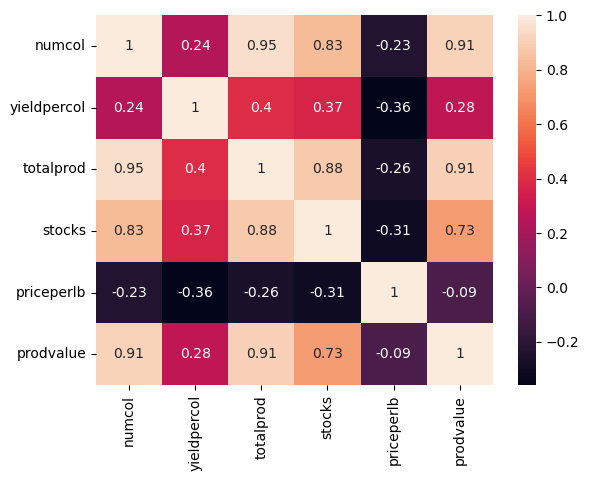

In [74]:
selected_columns_2 = ['numcol', 'yieldpercol', 'totalprod', 'stocks', 'priceperlb','prodvalue']
honey_df_selected_2= honey_df[selected_columns_2]

# Create pairplot
sns.heatmap(honey_df_selected_2.corr(),annot=True)
plt.show()

- positive correlation : one variable value get increases the oposite variable value will also be increase
- Negative correlation : one variable value get increases the oposite variable value will get decrease

Note:

By seeing above plot we can say that,
There is strong positive correlation between,
- Number of honey producing colonies vs total production
- Number of honey producing colonies vs total stocks(stocks held by producers)
- Number of honey producing colonies vs value of production
- total production vs stocks
- total production vs value of production
- stocks vs value of production

 

and There is negative correlation between,
- average price per pound vs Number of honey producing colonies
- average price per pound vs yield per colony
- average price per pound vs total production
- average price per pound vs stocks
